![Imgur](https://i.imgur.com/5pXzCIu.png)

# Data Science va Sun'iy Intellekt Praktikum

## 5-MODUL. Machine Learning

### Portfolio uchun vazifa: Toshkent shahrida uylarning narxini aniqlash.

Ushbu amaliyotda sizning vazifangiz berilgan ma`lumotlar asosida Toshkent shahridagi uylarning narxini aniqlash.

In [ ]:
import pandas as pd
df = pd.read_csv('https://raw.githubusercontent.com/anvarnarz/praktikum_datasets/main/housing_data_08-02-2021.csv')
df.head()

,location,district,rooms,size,level,max_levels,price
0,"город Ташкент, Юнусабадский район, Юнусабад 8-...",Юнусабадский,3,57,4,4,52000
1,"город Ташкент, Яккасарайский район, 1-й тупик ...",Яккасарайский,2,52,4,5,56000
2,"город Ташкент, Чиланзарский район, Чиланзар 2-...",Чиланзарский,2,42,4,4,37000
3,"город Ташкент, Чиланзарский район, Чиланзар 9-...",Чиланзарский,3,65,1,4,49500
4,"город Ташкент, Чиланзарский район, площадь Актепа",Чиланзарский,3,70,3,5,55000


# Ustunlar ta'rifi
- `location` - sotilayotgan uy manzili
- `district` - uy joylashgan tuman
- `rooms` - xonalar soni
- `size` - uy maydoni (kv.m)
- `level` - uy joylashgan qavat
- `max_levels` - ja'mi qavatlar soni
- `price` - uy narxi

## Vazifani CRSIP-DM Metolodgiyasi yordamida bajaring.
<img src="https://i.imgur.com/dzZnnYi.png" alt="CRISP-DM" width="800"/>

In [ ]:
df.describe()

,rooms,level,max_levels
count,7565.000000,7565.000000,7565.000000
mean,2.625644,3.699273,6.038202
std,1.085201,2.237275,2.613271
min,1.000000,1.000000,1.000000
25%,2.000000,2.000000,4.000000
50%,3.000000,3.000000,5.000000
75%,3.000000,5.000000,9.000000
max,10.000000,19.000000,25.000000


In [ ]:
df.shape

(7565, 7)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7565 entries, 0 to 7564
Data columns (total 7 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   location    7565 non-null   object
 1   district    7565 non-null   object
 2   rooms       7565 non-null   int64 
 3   size        7565 non-null   object
 4   level       7565 non-null   int64 
 5   max_levels  7565 non-null   int64 
 6   price       7565 non-null   object
dtypes: int64(3), object(4)
memory usage: 413.8+ KB


In [ ]:
df.columns = df.columns.str.strip()
cols = ["price", "size"]
df[cols] = (df[cols].apply(pd.to_numeric, errors="coerce"))
df[cols] = df[cols].fillna(df[cols].median())
#NaN qiymatlarga median qiymatlari berildi

df[cols] = df[cols].astype("int64")

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7565 entries, 0 to 7564
Data columns (total 7 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   location    7565 non-null   object
 1   district    7565 non-null   object
 2   rooms       7565 non-null   int64 
 3   size        7565 non-null   int64 
 4   level       7565 non-null   int64 
 5   max_levels  7565 non-null   int64 
 6   price       7565 non-null   int64 
dtypes: int64(5), object(2)
memory usage: 413.8+ KB


In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error

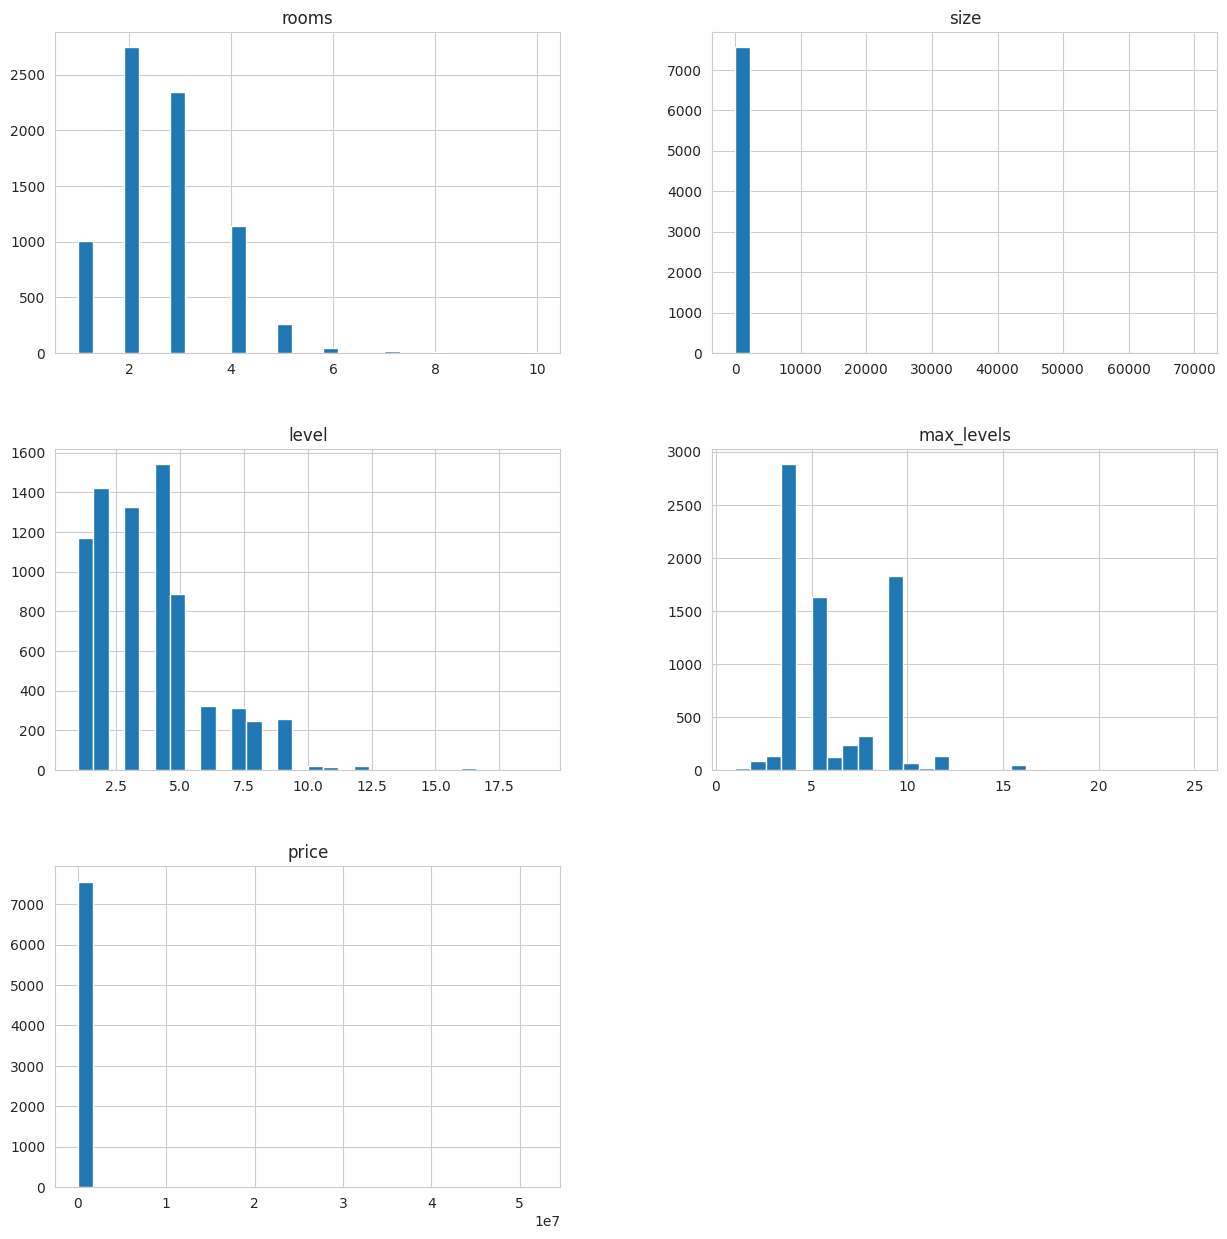

In [ ]:
%matplotlib inline
df.hist(bins=30,figsize=(15,15))
plt.show()

In [ ]:
df["location"].value_counts()

,count
location,
"город Ташкент, Чиланзарский район, Чиланзар",112
"город Ташкент, Яккасарайский район, Кушбеги",110
"город Ташкент, Мирзо-Улугбекский район, Буюк Ипак Йули",87
"город Ташкент, Яккасарайский район, Бабура",82
"город Ташкент, Учтепинский район, Чиланзар 24-й квартал",79
...,...
"город Ташкент, Яккасарайский район, 1-й тупик Шота Руставели",1
"город Ташкент, Юнусабадский район, Хусайни",1
"город Ташкент, Олмазорский район, Каракамиш2/4",1


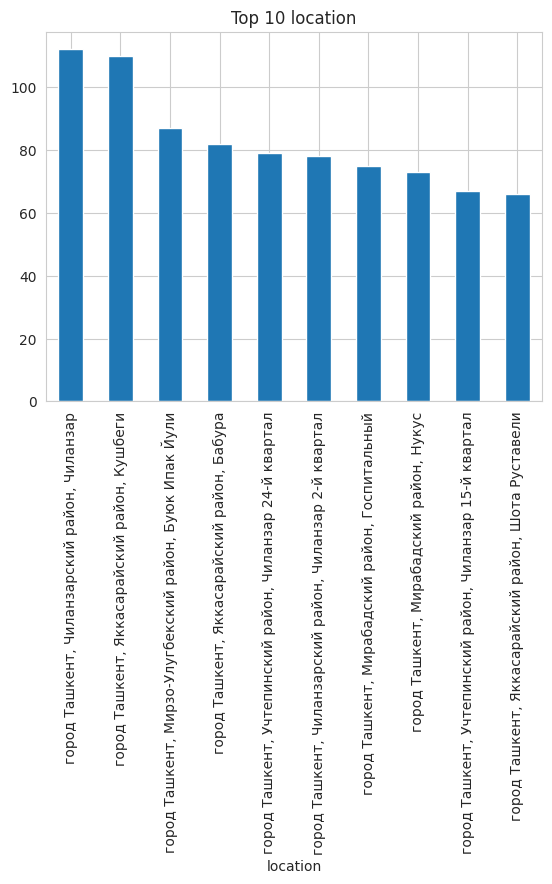

In [ ]:
# top lakatsiyalarni olib malumotlarni grafik ko'rinishida chiqarib olamiz chunki location ustuni malumotlar juda ko'p yozilgan
# malumot uchun chiqarildi
top_locations = df["location"].value_counts().head(10)
top_locations.plot(kind="bar")

import matplotlib.pyplot as plt
plt.xticks(rotation=90)
plt.title("Top 10 location")
plt.show()

/tmp/ipykernel_237/606675421.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_districts.index,y=top_districts.values,palette="viridis")   # chiroyli ranglar


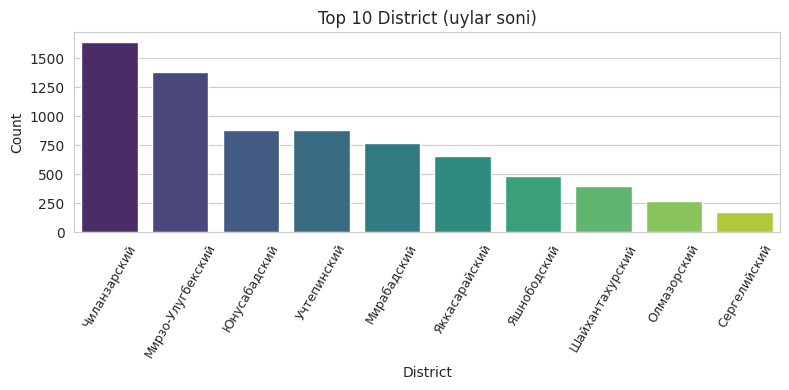

In [ ]:
#district bo'yicha o'rtacha narx
import matplotlib.pyplot as plt
import seaborn as sns

# style qo‘shamiz
sns.set_style("whitegrid")

plt.figure(figsize=(8,4))  # kichik va compact

top_districts = df["district"].value_counts().head(10)
sns.barplot(x=top_districts.index,y=top_districts.values,palette="viridis")   # chiroyli ranglar

plt.xticks(rotation=60, fontsize=9)
plt.title("Top 10 District (uylar soni)", fontsize=12)
plt.xlabel("District", fontsize=10)
plt.ylabel("Count", fontsize=10)

plt.tight_layout()  #chiroyli qiladi
plt.show()

In [ ]:
df = df.drop("location", axis=1)
# bu yerda location qismi olib tashlandi sababi OneHot qilinganda malumotlar 100+ bo'lib ketadi va modelga zarar yetishi mumkin

In [ ]:
#malumotlarni saralab olish
# feature / target
X = df.drop("price", axis=1)
y = df["price"]
# columns
num_cols = X.select_dtypes(include=["int64", "float64"]).columns
cat_cols = ["district"]

In [ ]:
#asosiy
#dfni train va test setlarga bo'lib olish
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [ ]:
#asosiy
preprocessor = ColumnTransformer([
    ("num", StandardScaler(), num_cols),
    ("cat", OneHotEncoder(handle_unknown="ignore"), cat_cols)
])

In [ ]:
#asosiy
#malumotlarni ketma ketlikda pipeline qilish va linear regressiyadan o'tqazish
model = Pipeline([
    ("prep", preprocessor),
    ("lr", LinearRegression())
])

In [ ]:
#asosiy
#modelni train qilish
model.fit(X_train, y_train)

Pipeline(steps=[('prep',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  Index(['rooms', 'size', 'level', 'max_levels'], dtype='object')),
                                                 ('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['district'])])),
                ('lr', LinearRegression())])

In [ ]:
#asosiy
#modelni bashorat qilish
preds = model.predict(X_test)

print(preds[:5])

[ 44703.40365743 -26484.70568792 155373.41388154 153728.94198576
 127831.53798372]


In [ ]:
#asosiy
#o'rtacha kvadratik xatolikni topish
from sklearn.metrics import mean_squared_error
import numpy as np

rmse = np.sqrt(mean_squared_error(y_test, preds))
print("RMSE:", rmse)

RMSE: 224608.49010051586


In [ ]:
preds = model.predict(X_test)
rmse = np.sqrt(mean_squared_error(y_test, preds))
y_test_reset = y_test.reset_index(drop=True)

df2 = pd.DataFrame({
    "actual_price": y_test_reset,
    "predicted_price": preds,
    "diff": y_test_reset - preds,
    "diff_%": (y_test_reset - preds) / y_test_reset * 100,

})
df2.head(5)
# bu yerda bashorat qilgan va asl qiymatdagi narxlarni solishtirish va % foiz qismida ko'rsatish


,actual_price,predicted_price,diff,diff_%
0,41000,44703.403657,-3703.403657,-9.032692
1,21000,-26484.705688,47484.705688,226.117646
2,91000,155373.413882,-64373.413882,-70.740015
3,95000,153728.941986,-58728.941986,-61.819939
4,88000,127831.537984,-39831.537984,-45.263111
